In [1]:
import numpy as np # linear algebra
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")

## Data Preprocessing


In [3]:
print("--- Dataset Head ---")
df.head()

--- Dataset Head ---


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
print("\n--- Missing Values Count ---")
print(df.isnull().sum())


--- Missing Values Count ---
id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


In [5]:
df.describe()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [6]:
df.columns

Index(['id', 'Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

### chekcing for null values and if there are any , it is filled with median or mean

In [7]:
colums =[  'Height', 'Weight', 'Duration', 'Heart_Rate','Body_Temp']
if df.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    
    for i in colums :
        df[i] = df[i].fillna(df[i].median())
    df['Age']=df["Age"].fillna(df['Age'].mean())
    print("Missing values handled.")

No missing values found.


### One hot encoding of gender column

In [8]:
df = pd.get_dummies(df, columns=['Sex'], drop_first=True,dtype = int)
df.head()

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Sex_male
0,0,36,189.0,82.0,26.0,101.0,41.0,150.0,1
1,1,64,163.0,60.0,8.0,85.0,39.7,34.0,0
2,2,51,161.0,64.0,7.0,84.0,39.8,29.0,0
3,3,20,192.0,90.0,25.0,105.0,40.7,140.0,1
4,4,38,166.0,61.0,25.0,102.0,40.6,146.0,0


### Scaling the numerical data 

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[colums] = scaler.fit_transform(df[colums])

### FInding outliers

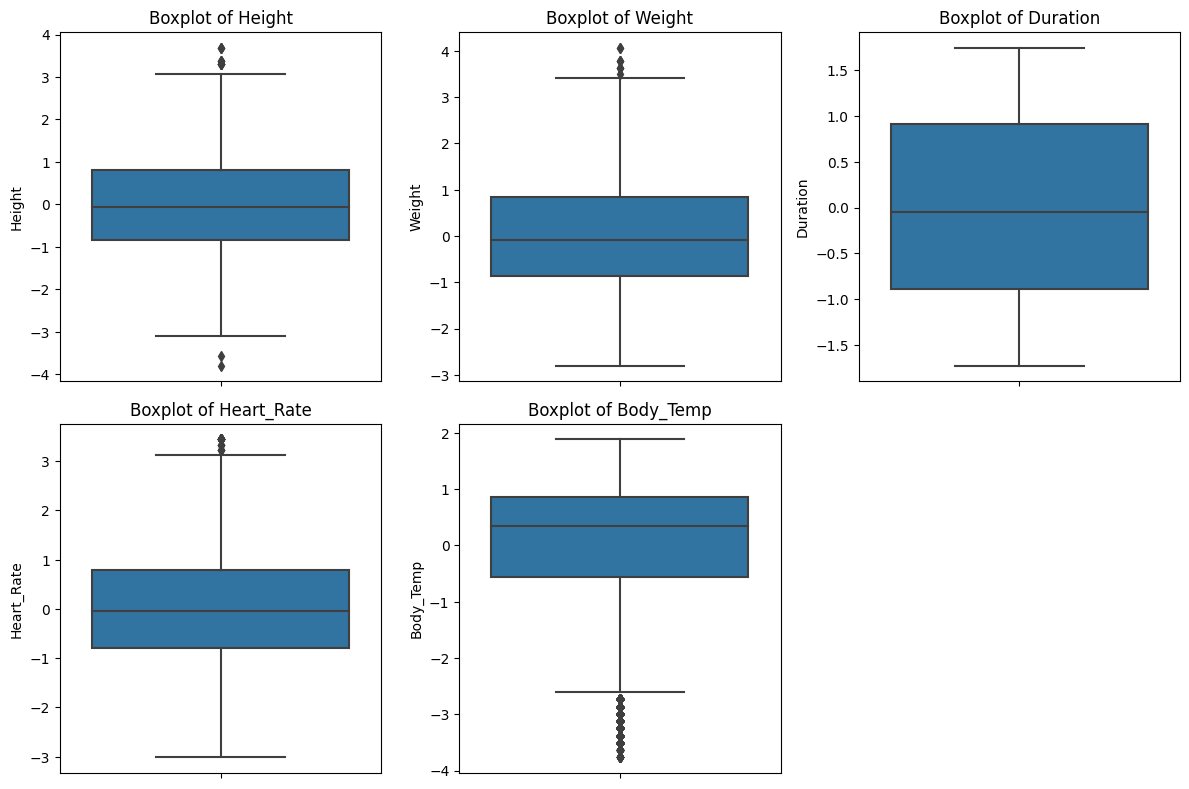

In [10]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(colums, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### removing outliers

In [11]:
for i in colums :
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3-Q1
    upper = Q3+1.5*IQR
    lower = Q1 - 1.5*IQR
    df[i]=df[i].clip(lower = lower , upper = upper)
Q1_cal = df["Calories"].quantile(0.25)
Q3_cal = df["Calories"].quantile(0.75)
IQR_cal = Q3-Q1
upper_cal = Q3_cal+1.5*IQR_cal
lower_cal = Q1_cal - 1.5*IQR_cal
df["Calories"]=df["Calories"].clip(lower = lower_cal , upper = upper_cal)

In [12]:
list (df.columns)

['id',
 'Age',
 'Height',
 'Weight',
 'Duration',
 'Heart_Rate',
 'Body_Temp',
 'Calories',
 'Sex_male']

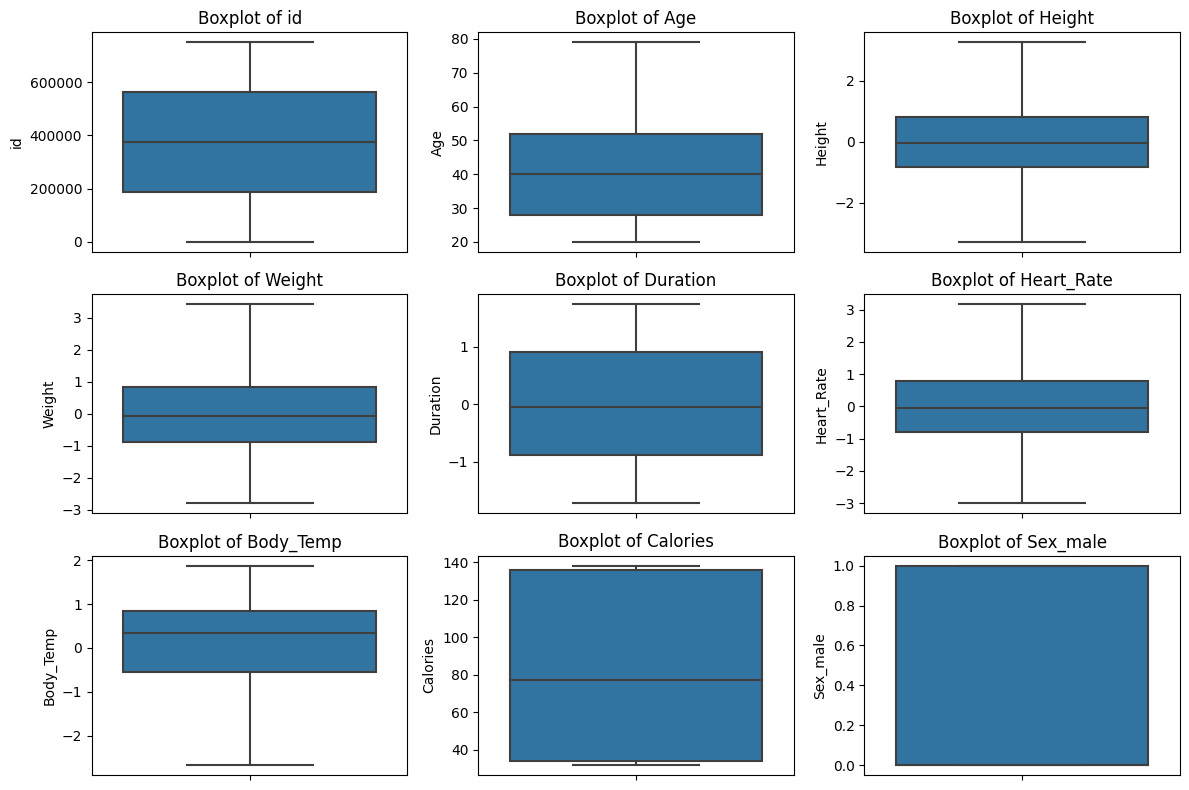

In [13]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(list (df.columns), 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## EDA 